In [1]:
TOKENIZER_NAME = "google/gemma-3-1b-it"
QUANTILES      = [0.90, 0.95]
SPLIT_COLORS   = {"train": "#1f77b4", "validation": "#ff7f0e", "test": "#2ca02c"}

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

In [3]:
ds = load_dataset("csebuetnlp/xlsum", "ukrainian", trust_remote_code=True)
splits = {name: ds[name].to_pandas() for name in ["train", "validation", "test"]}
{k: len(v) for k, v in splits.items()}

{'train': 43201, 'validation': 5399, 'test': 5399}

## Token counts

In [4]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
print(f"Loaded: {tokenizer.__class__.__name__}  ({TOKENIZER_NAME})")

Loaded: GemmaTokenizer  (google/gemma-3-1b-it)


In [5]:
def batch_token_counts(series, batch_size=512):
    texts, counts = series.tolist(), []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i : i + batch_size],
            add_special_tokens=False,
            truncation=False,
        )
        counts.extend(len(ids) for ids in enc["input_ids"])
    return counts

for name, df in splits.items():
    for col in ("title", "summary", "text"):
        df[f"{col}_tokens"] = batch_token_counts(df[col])
    print(f"{name}: done")

train: done
validation: done
test: done


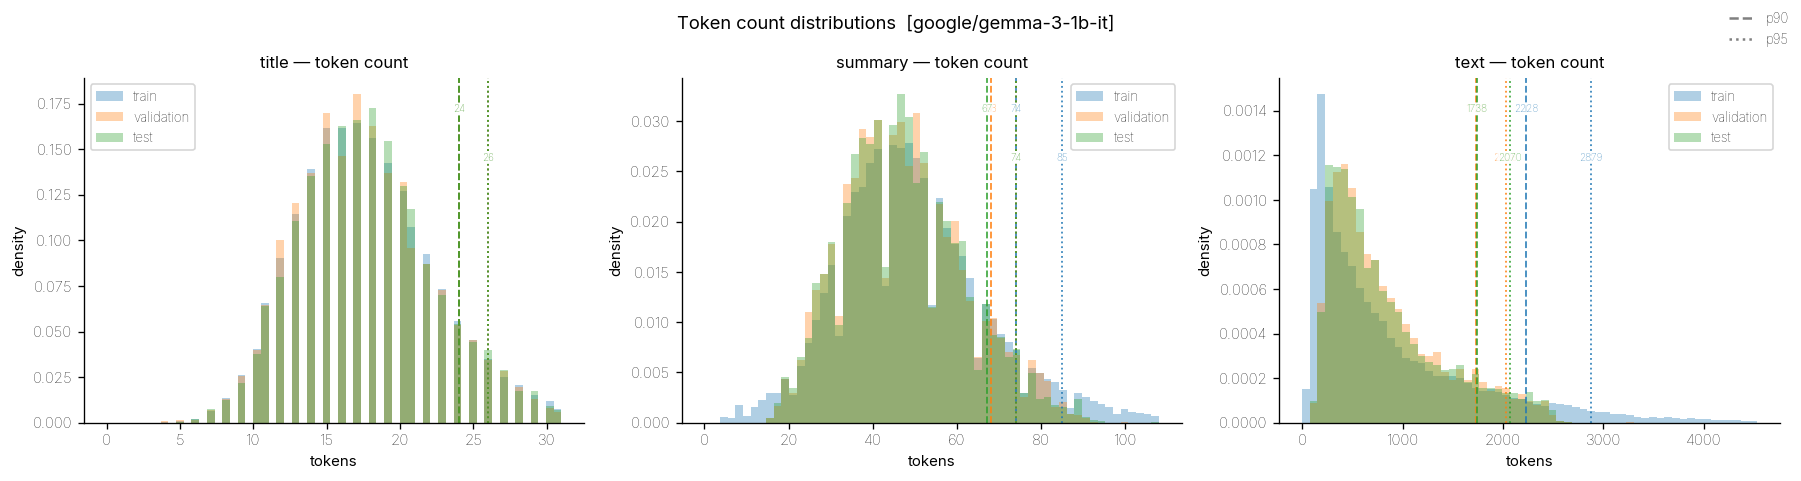

In [6]:
def plot_token_dist(ax, field):
    col = f"{field}_tokens"
    all_vals = pd.concat([df[col] for df in splits.values()])
    bins = np.linspace(0, all_vals.quantile(0.99), 60)

    for name, df in splits.items():
        ax.hist(df[col], bins=bins, alpha=0.35, color=SPLIT_COLORS[name],
                label=name, density=True)

    ymax = ax.get_ylim()[1]
    y_levels = [0.90, 0.76]  # vertical label positions per quantile

    for name, df in splits.items():
        for i, q in enumerate(QUANTILES):
            qv = int(df[col].quantile(q))
            ax.axvline(qv, color=SPLIT_COLORS[name],
                       linestyle="--" if i == 0 else ":",
                       linewidth=1.1, alpha=0.85)
            ax.text(qv, ymax * y_levels[i], str(qv),
                    color=SPLIT_COLORS[name], fontsize=6, ha="center",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"))

    ax.set_title(f"{field} — token count", fontsize=10)
    ax.set_xlabel("tokens")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, field in zip(axes, ("title", "summary", "text")):
    plot_token_dist(ax, field)

q_handles = [
    plt.Line2D([], [], linestyle="--", color="grey", label="p90"),
    plt.Line2D([], [], linestyle=":",  color="grey", label="p95"),
]
fig.legend(handles=q_handles, loc="upper right", fontsize=8, frameon=False)
plt.suptitle(f"Token count distributions  [{TOKENIZER_NAME}]", fontsize=11)
plt.tight_layout()
plt.show()

## Sentence counts

In [7]:
from tokenize_uk import tokenize_sents

def count_sentences(text):
    return len(tokenize_sents(text or ""))

for name, df in splits.items():
    for col in ("text", "summary"):
        df[f"{col}_sents"] = df[col].map(count_sentences)
    print(f"{name}: done")

train: done
validation: done
test: done


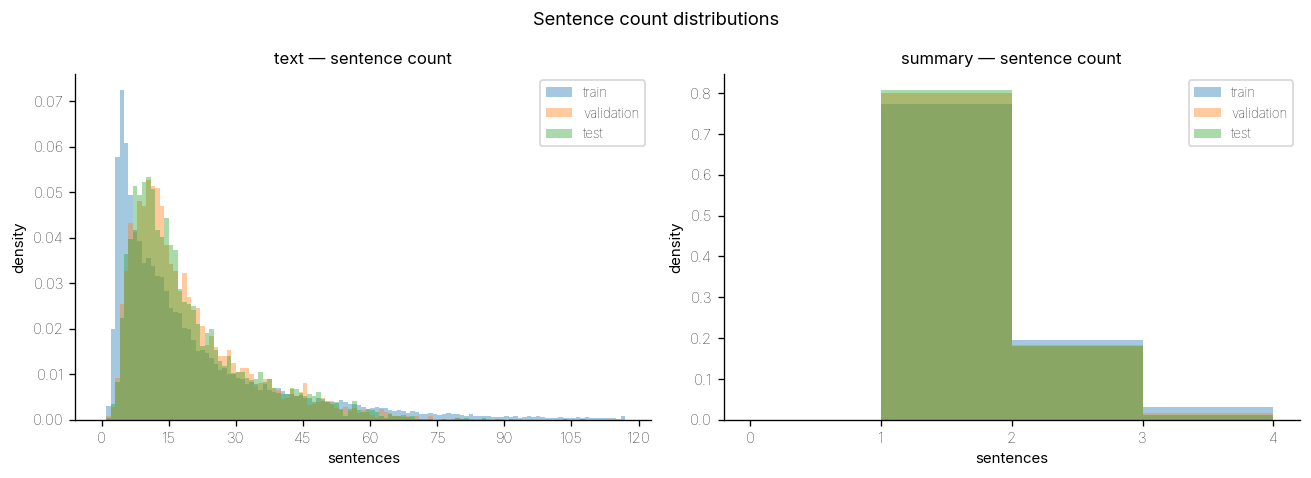

In [8]:
def plot_sent_dist(ax, field):
    col = f"{field}_sents"
    all_vals = pd.concat([df[col] for df in splits.values()])
    bins = np.arange(0, int(all_vals.quantile(0.99)) + 2)

    for name, df in splits.items():
        ax.hist(df[col], bins=bins, alpha=0.40, color=SPLIT_COLORS[name],
                label=name, density=True)

    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_title(f"{field} — sentence count", fontsize=10)
    ax.set_xlabel("sentences")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, field in zip(axes, ("text", "summary")):
    plot_sent_dist(ax, field)

plt.suptitle("Sentence count distributions", fontsize=11)
plt.tight_layout()
plt.show()